In [1]:
import sys
#! {sys.executable} -m pip install ucimlrepo

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from ucimlrepo import fetch_ucirepo

wine = fetch_ucirepo(id=186)

X_raw = wine.data.features.reset_index(drop=True)
y_raw = wine.data.targets.reset_index(drop=True)

df = pd.concat([X_raw, y_raw], axis=1)

print(df.shape)
print(df.isna().sum())
df.head()

ConnectionError: Error connecting to server

In [ ]:
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
df.to_csv("Dataset.csv",index=False)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 609.2 KB


In [ ]:
target_col = "quality"
feature_cols = [c for c in df.columns if c != target_col]  # 11 continuous features

y = df[target_col].values.astype(float)
print(feature_cols)

['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [ ]:
def gradient_descent_fixed(x, y, lr=0.05, epochs=100):
    """
    Runs exactly `epochs` iterations.
    Returns history of beta0, beta1, MSE, MAE at every iteration.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)

    beta0, beta1 = 0.0, 0.0
    hist = {"iter": [], "beta0": [], "beta1": [], "mse": [], "mae": []}

    for k in range(epochs):
        y_pred = beta0 + beta1 * x
        error = y_pred - y

        mse = np.mean(error ** 2)
        mae = np.mean(np.abs(error))

        hist["iter"].append(k)
        hist["beta0"].append(beta0)
        hist["beta1"].append(beta1)
        hist["mse"].append(mse)
        hist["mae"].append(mae)

        d_beta0 = (2 / n) * np.sum(error)
        d_beta1 = (2 / n) * np.sum(error * x)

        beta0 -= lr * d_beta0
        beta1 -= lr * d_beta1

    return beta0, beta1, pd.DataFrame(hist)

In [ ]:
def gradient_descent_converge(x, y, lr=0.01, tol=1e-6, max_iter=200000):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n = len(x)

    beta0, beta1 = 0.0, 0.0
    hist = {"iter": [], "beta0": [], "beta1": [], "mse": [], "mae": []}

    for k in range(max_iter):
        y_pred = beta0 + beta1 * x
        error = y_pred - y

        mse = np.mean(error ** 2)
        mae = np.mean(np.abs(error))

        # --- divergence guard ---
        if not np.isfinite(mse) or not np.isfinite(beta0) or not np.isfinite(beta1):
            raise FloatingPointError(
                f"Diverged at iter {k}: beta0={beta0}, beta1={beta1}. "
                f"Try a smaller lr (currently {lr})."
            )

        hist["iter"].append(k)
        hist["beta0"].append(beta0)
        hist["beta1"].append(beta1)
        hist["mse"].append(mse)
        hist["mae"].append(mae)

        d_beta0 = (2 / n) * np.sum(error)
        d_beta1 = (2 / n) * np.sum(error * x)

        beta0_new = beta0 - lr * d_beta0
        beta1_new = beta1 - lr * d_beta1

        if abs(beta0_new - beta0) <= tol and abs(beta1_new - beta1) <= tol:
            beta0, beta1 = beta0_new, beta1_new
            y_pred = beta0 + beta1 * x
            error = y_pred - y
            hist["iter"].append(k + 1)
            hist["beta0"].append(beta0)
            hist["beta1"].append(beta1)
            hist["mse"].append(np.mean(error ** 2))
            hist["mae"].append(np.mean(np.abs(error)))
            break

        beta0, beta1 = beta0_new, beta1_new

    return beta0, beta1, pd.DataFrame(hist)

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from scipy import stats

In [ ]:
def r_squared(y, y_pred):
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot

def check_residual_normality(residuals, feature_name, plot=True):
    shapiro_stat, shapiro_p = stats.shapiro(residuals if len(residuals) <= 5000
                                             else np.random.choice(residuals, 5000, replace=False))
    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].hist(residuals, bins=30, edgecolor="k")
        axes[0].set_title(f"Residual histogram — {feature_name}")
        stats.probplot(residuals, dist="norm", plot=axes[1])
        axes[1].set_title(f"Q-Q plot — {feature_name}")
        plt.tight_layout()
        plt.savefig(f"residuals_{feature_name}.png", dpi=100)
        plt.show()
    return shapiro_stat, shapiro_p

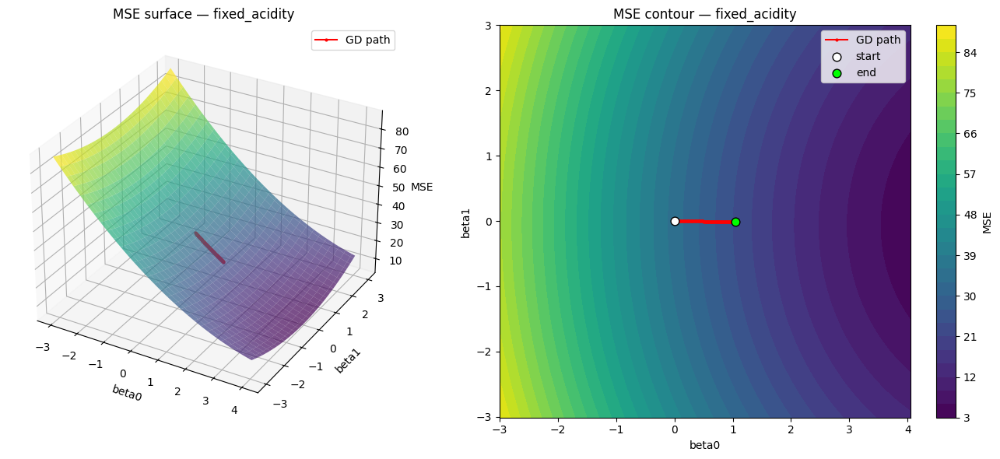

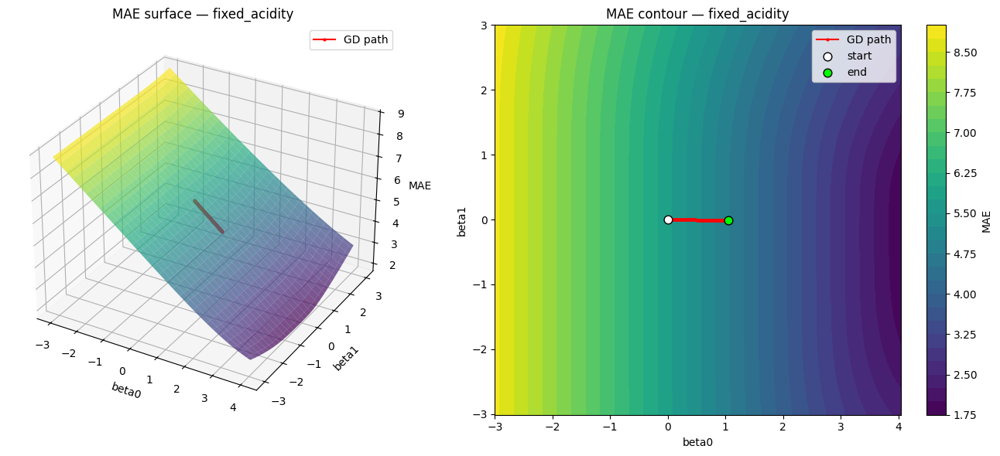

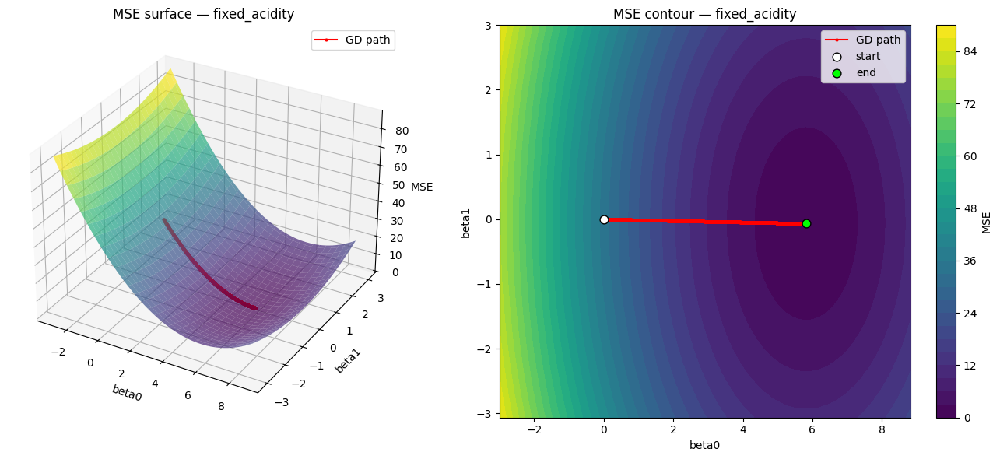

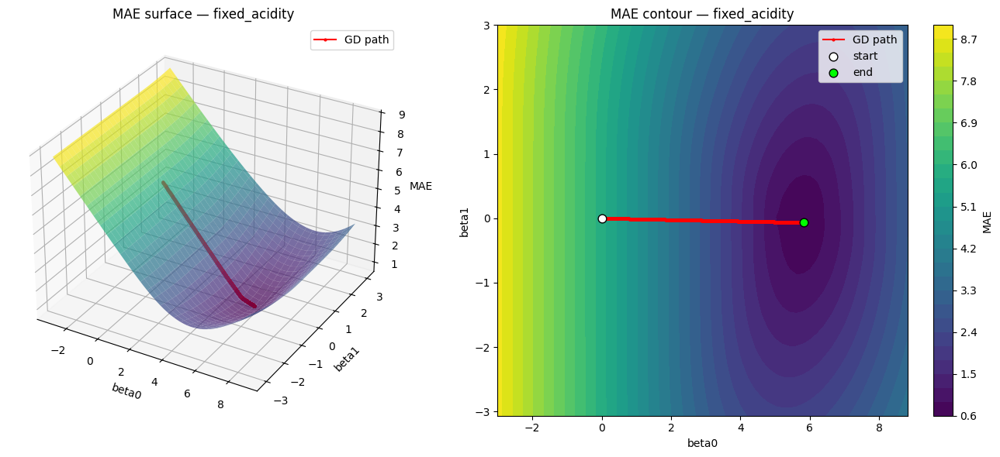

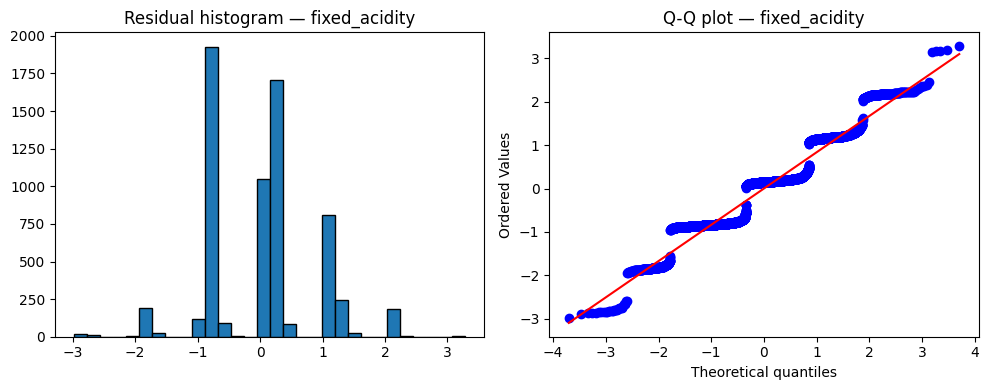

...

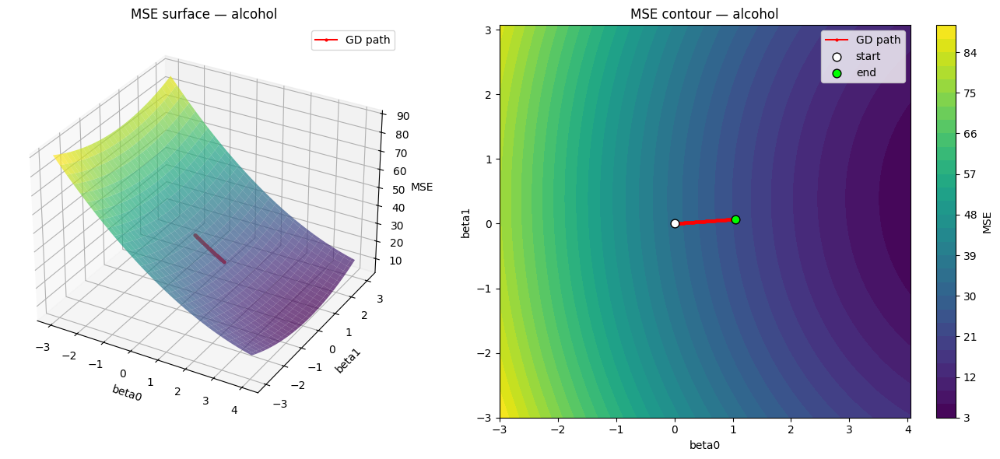

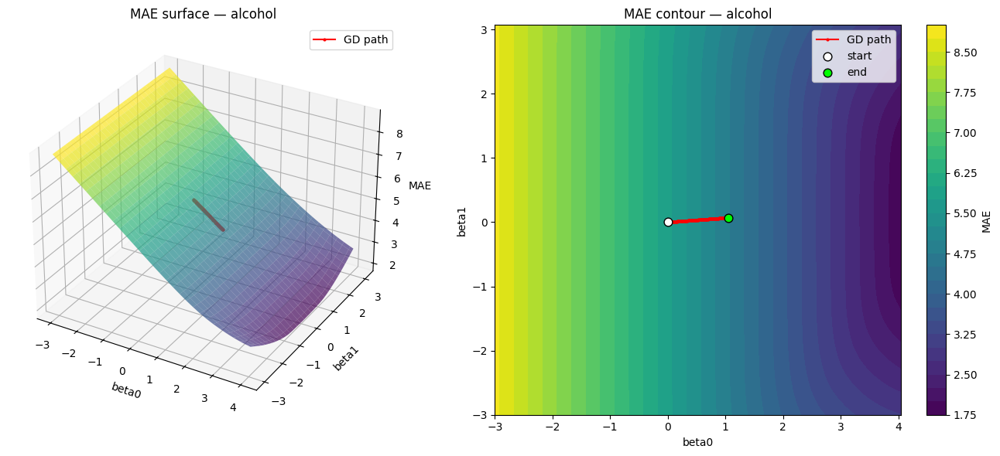

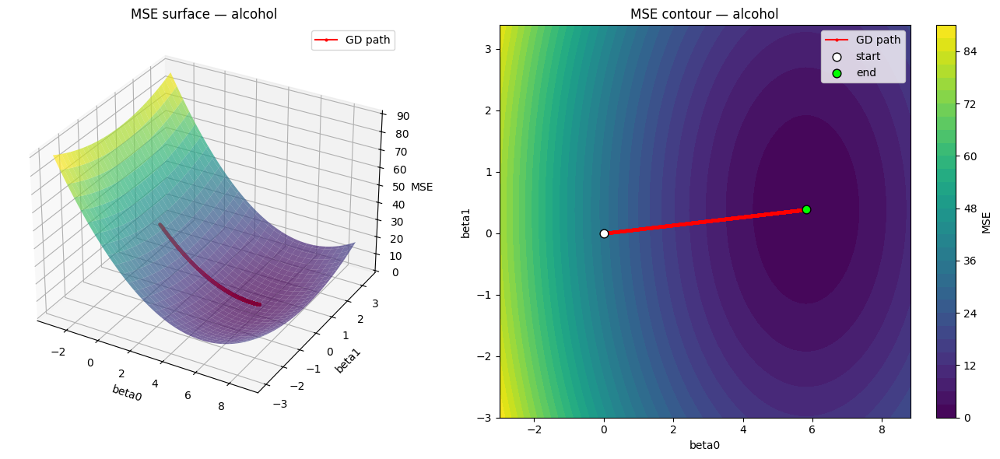

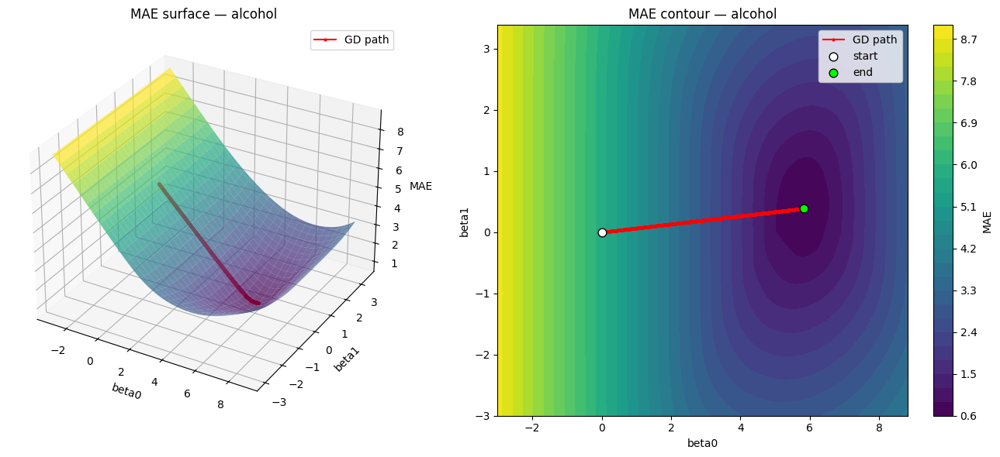

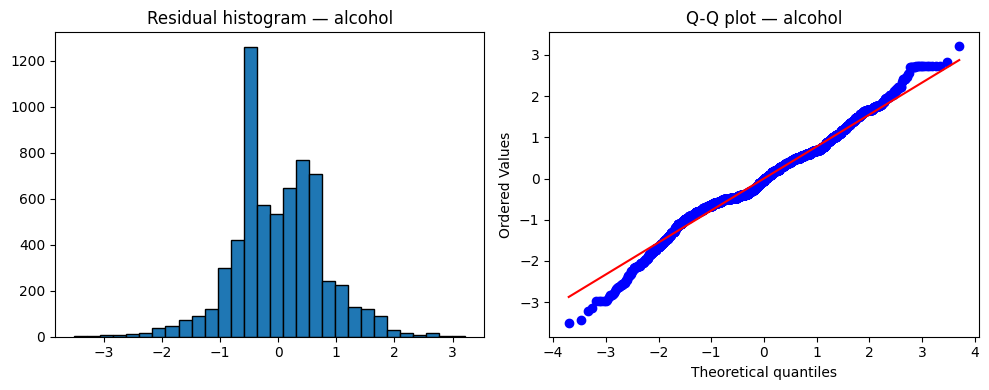

,feature,beta0_fixed100,beta1_fixed100,beta0_converged,beta1_converged,iters_to_converge,R2,shapiro_stat,shapiro_p,residuals_normal(p>0.05)
10,alcohol,1.055647,0.070391,5.817879,0.387940,4679,0.197419,0.982780,3.279675e-24,False
7,density,1.055647,-0.048456,5.817879,-0.267049,4679,0.093549,0.990334,5.264896e-18,False
1,volatile_acidity,1.055647,-0.042094,5.817879,-0.231986,4679,0.070596,0.972546,6.056166e-30,False
4,chlorides,1.055647,-0.031790,5.817879,-0.175204,4679,0.040266,0.945342,1.373599e-39,False
2,citric_acid,1.055647,0.013550,5.817879,0.074679,4679,0.007315,0.927866,7.139867e-44,False
0,fixed_acidity,1.055647,-0.012158,5.817879,-0.067006,4679,0.005889,0.921626,3.374069e-45,False
5,free_sulfur_dioxide,1.055647,0.008787,5.817879,0.048426,4679,0.003076,0.913432,8.173403e-47,False
6,total_sulfur_dioxide,1.055647,-0.006557,5.817879,-0.036134,4679,0.001712,0.906380,4.160160e-48,False
9,sulphates,1.055647,0.006097,5.817879,0.033602,4679,0.001481,0.905106,2.477227e-48,False
3,residual_sugar,1.055647,-0.005859,5.817879,-0.032288,4679,0.001367,0.903115,1.114968e-48,False


In [ ]:
results_summary = []

for feat in feature_cols:
    try:
        x_raw = df[feat].values.astype(float)
        x_norm = (x_raw - x_raw.mean()) / x_raw.std()

        b0_fixed, b1_fixed, hist_fixed = gradient_descent_fixed(x_norm, y, lr=0.001, epochs=100)
        hist_fixed.to_csv(f"gd_fixed100_{feat}.csv", index=False)

        b0_conv, b1_conv, hist_conv = gradient_descent_converge(x_norm, y, lr=0.001, tol=1e-6, max_iter=500000)
        hist_conv.to_csv(f"gd_converge_{feat}.csv", index=False)
        # surface + contour for the fixed-100-iteration run
        plot_surface_and_contour(x_norm, y, hist_fixed, feat, loss="mse")
        plot_surface_and_contour(x_norm, y, hist_fixed, feat, loss="mae")

        # surface + contour for the converged run
        plot_surface_and_contour(x_norm, y, hist_conv, feat, loss="mse")
        plot_surface_and_contour(x_norm, y, hist_conv, feat, loss="mae")

        y_pred = b0_conv + b1_conv * x_norm
        r2 = r_squared(y, y_pred)
        residuals = y - y_pred
        shapiro_stat, shapiro_p = check_residual_normality(residuals, feat, plot=True)

        results_summary.append({
            "feature": feat,
            "beta0_fixed100": b0_fixed, "beta1_fixed100": b1_fixed,
            "beta0_converged": b0_conv, "beta1_converged": b1_conv,
            "iters_to_converge": len(hist_conv),
            "R2": r2, "shapiro_stat": shapiro_stat, "shapiro_p": shapiro_p,
            "residuals_normal(p>0.05)": shapiro_p > 0.05
        })

    except FloatingPointError as e:
        print(f"[SKIPPED] {feat}: {e}")   # <-- read this output carefully now
        continue

if len(results_summary) == 0:
    raise RuntimeError("Every feature diverged — lr is still too high. Try lr=0.0001.")

results_df = pd.DataFrame(results_summary).sort_values("R2", ascending=False)
results_df.to_csv("summary_all_features.csv", index=False)
results_df

In [ ]:
def compute_loss_surface(x, y, beta0_range, beta1_range, loss="mse"):
    """
    Returns a meshgrid B0, B1 and the corresponding loss Z, for plotting.
    loss: "mse" or "mae"
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    B0, B1 = np.meshgrid(beta0_range, beta1_range)
    Z = np.zeros_like(B0)

    for i in range(B0.shape[0]):
        for j in range(B0.shape[1]):
            y_pred = B0[i, j] + B1[i, j] * x
            error = y_pred - y
            if loss == "mse":
                Z[i, j] = np.mean(error ** 2)
            else:
                Z[i, j] = np.mean(np.abs(error))

    return B0, B1, Z

In [ ]:
def plot_surface_and_contour(x, y, hist, feat, loss="mse", margin=3, resolution=60):
    """
    hist: DataFrame with columns beta0, beta1 (the GD path) from gradient_descent_fixed/converge
    Plots a 3D surface and a 2D contour of the loss, with the GD path overlaid.
    """
    b0_path = hist["beta0"].values
    b1_path = hist["beta1"].values

    # build a grid centered around the path, wide enough to show the bowl
    b0_range = np.linspace(b0_path.min() - margin, b0_path.max() + margin, resolution)
    b1_range = np.linspace(b1_path.min() - margin, b1_path.max() + margin, resolution)

    B0, B1, Z = compute_loss_surface(x, y, b0_range, b1_range, loss=loss)
    path_z = hist[loss].values

    fig = plt.figure(figsize=(14, 6))

    # --- 3D surface ---
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax1.plot_surface(B0, B1, Z, cmap="viridis", alpha=0.7, edgecolor="none")
    ax1.plot(b0_path, b1_path, path_z, color="red", marker="o", markersize=2,
              linewidth=1.5, label="GD path")
    ax1.set_xlabel("beta0")
    ax1.set_ylabel("beta1")
    ax1.set_zlabel(loss.upper())
    ax1.set_title(f"{loss.upper()} surface — {feat}")
    ax1.legend()

    # --- contour ---
    ax2 = fig.add_subplot(1, 2, 2)
    cp = ax2.contourf(B0, B1, Z, levels=30, cmap="viridis")
    ax2.plot(b0_path, b1_path, color="red", marker="o", markersize=2,
              linewidth=1.5, label="GD path")
    ax2.scatter(b0_path[0], b1_path[0], color="white", edgecolor="black", s=60,
                zorder=5, label="start")
    ax2.scatter(b0_path[-1], b1_path[-1], color="lime", edgecolor="black", s=60,
                zorder=5, label="end")
    fig.colorbar(cp, ax=ax2, label=loss.upper())
    ax2.set_xlabel("beta0")
    ax2.set_ylabel("beta1")
    ax2.set_title(f"{loss.upper()} contour — {feat}")
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f"surface_contour_{loss}_{feat}.png", dpi=100)
    plt.show()